### My Question
What is the probability of rolling an even number on one roll of a fair six-sided die?

### My Study
1. The **random process** being simulated is rolling one fair six-sided die.
2. One **trial** is one roll of the die. The possible **outcomes** are 1, 2, 3, 4, 5, and 6.
3. The **event** I am interested in is rolling an even number. The outcomes included in this event are 2, 4, and 6.

### My Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(42)

In [2]:
number_of_rolls = 1000
rolls = rng.integers(1, 7, size=number_of_rolls)

die_results = pd.DataFrame({
    "roll_number": np.arange(1, number_of_rolls + 1),
    "outcome": rolls
})
die_results["is_even"] = die_results["outcome"].isin([2, 4, 6])
die_results["relative_frequency_even"] = die_results["is_even"].cumsum() / die_results["roll_number"]

die_results.head(10)

,roll_number,outcome,is_even,relative_frequency_even
0,1,1,False,0.000000
1,2,5,False,0.000000
2,3,4,True,0.333333
3,4,3,False,0.250000
4,5,3,False,0.200000
5,6,6,True,0.333333
6,7,1,False,0.285714
7,8,5,False,0.250000
8,9,2,True,0.333333
9,10,1,False,0.300000


In [3]:
even_count = die_results["is_even"].sum()
empirical_probability = even_count / number_of_rolls
theoretical_probability = 3 / 6

print(f"Number of even rolls: {even_count} out of {number_of_rolls}")
print(f"Empirical probability of rolling an even number: {empirical_probability:.3f}")
print(f"Theoretical probability of rolling an even number: {theoretical_probability:.3f}")

Number of even rolls: 484 out of 1000
Empirical probability of rolling an even number: 0.484
Theoretical probability of rolling an even number: 0.500


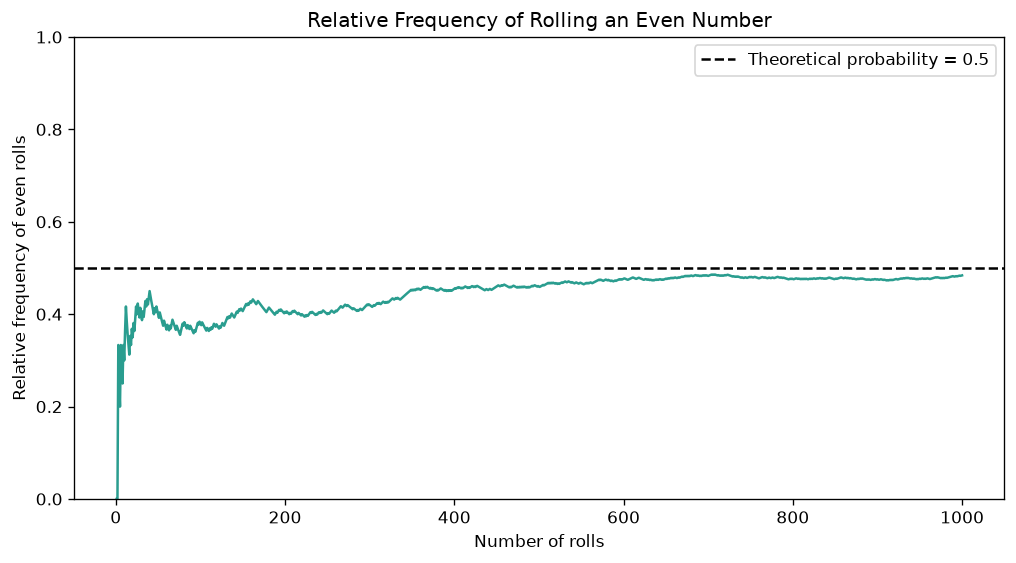

In [4]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=die_results,
    x="roll_number",
    y="relative_frequency_even",
    color="#2a9d8f"
)
plt.axhline(theoretical_probability, color="black", linestyle="--", label="Theoretical probability = 0.5")
plt.title("Relative Frequency of Rolling an Even Number")
plt.xlabel("Number of rolls")
plt.ylabel("Relative frequency of even rolls")
plt.ylim(0, 1)
plt.legend()
plt.show()

### My Conclusion
The theoretical probability of rolling an even number on a fair six-sided die is 3/6, or 0.5, because three of the six outcomes are even: 2, 4, and 6. In my simulation, 484 of the 1000 rolls were even, so the empirical probability was 0.484.

The graph above shows the relative frequency of even rolls after each roll. At the beginning, the line moves around more because there are only a few trials. As more rolls are added, the relative frequency settles closer to the theoretical probability line at 0.5. This supports the answer because it shows that the long-run relative frequency is close to the theoretical probability.